<a href="https://colab.research.google.com/github/MaxSimo72/Colab_Repository/blob/main/Yahoo_Finance_v01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance

In [ ]:
!pip install --upgrade yfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 2.7 MB/s eta 0:00:00
  Attempting uninstall: yfinance
    Found existing installation: yfinance 0.2.63
    Uninstalling yfinance-0.2.63:
      Successfully uninstalled yfinance-0.2.63


In [ ]:
import yfinance as yf
import pandas as pd

In [ ]:
#GENERALI
#data = yf.download("G.MI", start="1991-01-01", end="2024-12-31")

#ALLIANZ
data = yf.download("ALV.DE", start="1997-01-01", end="2024-12-31")

closing_prices = data['Close']
volume = data['Volume']

print(closing_prices)
print(volume)

/tmp/ipython-input-4-1936089066.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("ALV.DE", start="1997-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed

Ticker          ALV.DE
Date                  
1997-01-01   54.302841
1997-01-02   52.845791
1997-01-03   53.351963
1997-01-06   53.274548
1997-01-07   52.634056
...                ...
2024-12-19  284.622162
2024-12-20  282.417297
2024-12-23  282.033844
2024-12-27  282.896606
2024-12-30  283.663513

[7174 rows x 1 columns]
Ticker       ALV.DE
Date               
1997-01-01        0
1997-01-02   104815
1997-01-03    62378
1997-01-06    43460
1997-01-07    51640
...             ...
2024-12-19   829397
2024-12-20  1307177
2024-12-23   446106
2024-12-27   550402
2024-12-30   369274

[7174 rows x 1 columns]


In [ ]:
data

Price,Close,High,Low,Open,Volume
Ticker,ALV.DE,ALV.DE,ALV.DE,ALV.DE,ALV.DE
Date,,,,,
1997-01-01,54.302841,54.302841,54.302841,54.302841,0
1997-01-02,52.845791,53.313272,52.692498,53.158074,104815
1997-01-03,53.351963,53.351963,53.022223,53.351963,62378
1997-01-06,53.274548,54.225061,52.934942,54.127918,43460
1997-01-07,52.634056,52.964172,52.537296,52.964172,51640
...,...,...,...,...,...
2024-12-19,284.622162,285.964261,282.992480,285.293226,829397
2024-12-20,282.417297,283.280073,279.062034,282.800750,1307177


In [ ]:
data.dtypes

,,0
Price,Ticker,
Close,ALV.DE,float64
High,ALV.DE,float64
Low,ALV.DE,float64
Open,ALV.DE,float64
Volume,ALV.DE,int64


In [ ]:
# Assuming 1y is always 365 days
data['1Y_Rolling_Return'] = data['Close'].pct_change(periods=365)

# Assuming 3y is always 1095 days
data['3Y_Rolling_Return'] = data['Close'].pct_change(periods=1095)

In [ ]:
num_rows = len(data)
print(f"Number of rows in the dataset: {num_rows}")

# Filter out NaN values using .notna()
filtered_data_1Y = data[data['1Y_Rolling_Return'].notna()]
filtered_data_3Y = data[data['3Y_Rolling_Return'].notna()]

num_rows_1Y_filtered_data = len(filtered_data_1Y)
print(f"Number of rows in the 1Y filtered dataset: {num_rows_1Y_filtered_data}")

num_rows_3Y_filtered_data = len(filtered_data_3Y)
print(f"Number of rows in the 3Y filtered dataset: {num_rows_3Y_filtered_data}")

Number of rows in the dataset: 7174
Number of rows in the 1Y filtered dataset: 6809
Number of rows in the 3Y filtered dataset: 6079


In [ ]:
nan_count_1Y = data['1Y_Rolling_Return'].isna().sum()
nan_count_3Y = data['3Y_Rolling_Return'].isna().sum()

In [ ]:
print(f"Number of NaN values in 1Y_Rolling_Return: {nan_count_1Y}")
print(f"Number of NaN values in 3Y_Rolling_Return: {nan_count_3Y}")

Number of NaN values in 1Y_Rolling_Return: 365
Number of NaN values in 3Y_Rolling_Return: 1095


In [ ]:
# data.to_csv('stock_data.csv', index=True)

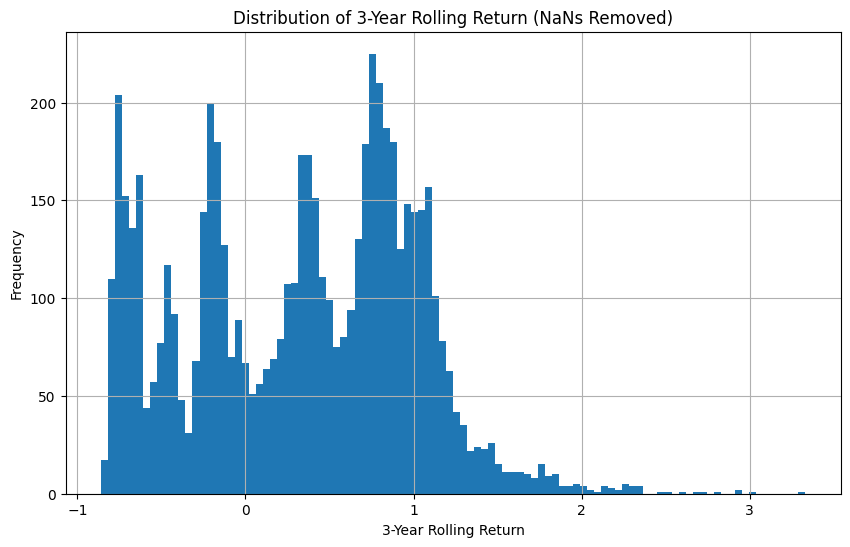

In [ ]:
import matplotlib.pyplot as plt

# Filter out NaN values using .notna()

plt.figure(figsize=(10, 6))
plt.hist(filtered_data_3Y['3Y_Rolling_Return'], bins=100)
plt.title('Distribution of 3-Year Rolling Return (NaNs Removed)')
plt.xlabel('3-Year Rolling Return')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

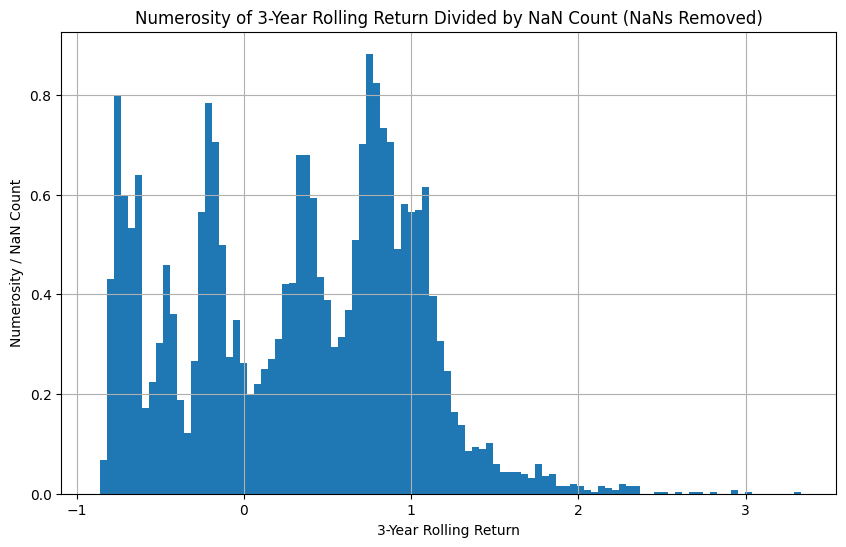

In [ ]:
import matplotlib.pyplot as plt

# Filter out NaN values using .notna()
filtered_data_3Y = data[data['3Y_Rolling_Return'].notna()]

plt.figure(figsize=(10, 6))

# Calculate the frequency of each bin
hist, bins, _ = plt.hist(filtered_data_3Y['3Y_Rolling_Return'], bins=100, density=True) # Added density=True

# Divide the frequency of each bin by nan_count_3Y
modified_hist = hist / nan_count_3Y

# Create a bar plot with modified frequencies
plt.bar(bins[:-1], modified_hist, width=bins[1] - bins[0])

plt.title('Numerosity of 3-Year Rolling Return Divided by NaN Count (NaNs Removed)')
plt.xlabel('3-Year Rolling Return')
plt.ylabel('Numerosity / NaN Count') # Changed y-axis label
plt.grid(True)
plt.show()

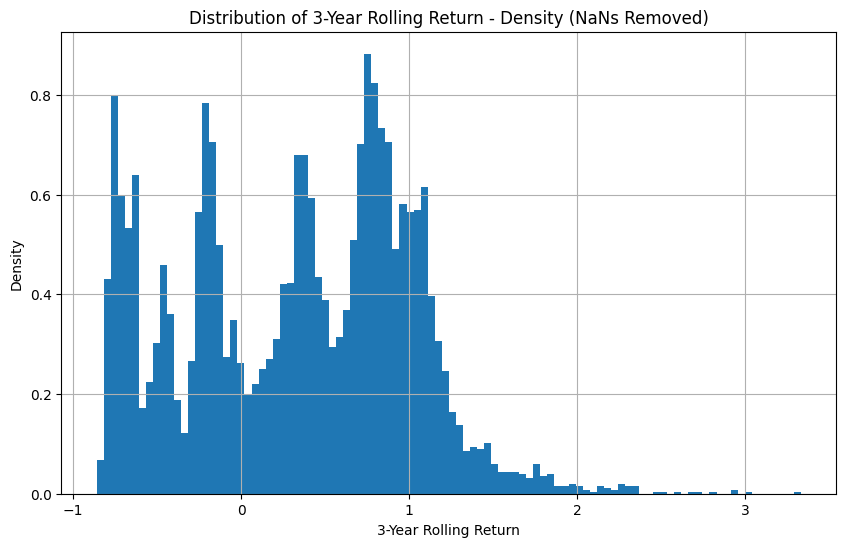

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(filtered_data_3Y['3Y_Rolling_Return'], bins=100, density=True)
plt.title('Distribution of 3-Year Rolling Return - Density (NaNs Removed)')
plt.xlabel('3-Year Rolling Return')
plt.ylabel('Density')  # Changed y-axis label to 'Density'
plt.grid(True)
plt.show()

In [ ]:
negative_3Y_return_count = (filtered_data_3Y['3Y_Rolling_Return'] < 0).sum()
print(f"Number of times with negative 3Y Rolling Return: {negative_3Y_return_count}")

Number of times with negative 3Y Rolling Return: 2157


In [ ]:
positive_3Y_return_count = (filtered_data_3Y['3Y_Rolling_Return'] > 0).sum()
print(f"Number of times with positive 3Y Rolling Return: {positive_3Y_return_count}")

Number of times with positive 3Y Rolling Return: 3922


In [ ]:
total_count = negative_3Y_return_count + positive_3Y_return_count
print(f"Total count: {total_count}")

Total count: 6079


In [ ]:
print(f"% of times with negative 3Y Rolling Return: {(negative_3Y_return_count/total_count)*100}")
print(f"% of times with positive 3Y Rolling Return: {(positive_3Y_return_count/total_count)*100}")

% of times with negative 3Y Rolling Return: 35.482809672643526
% of times with positive 3Y Rolling Return: 64.51719032735647


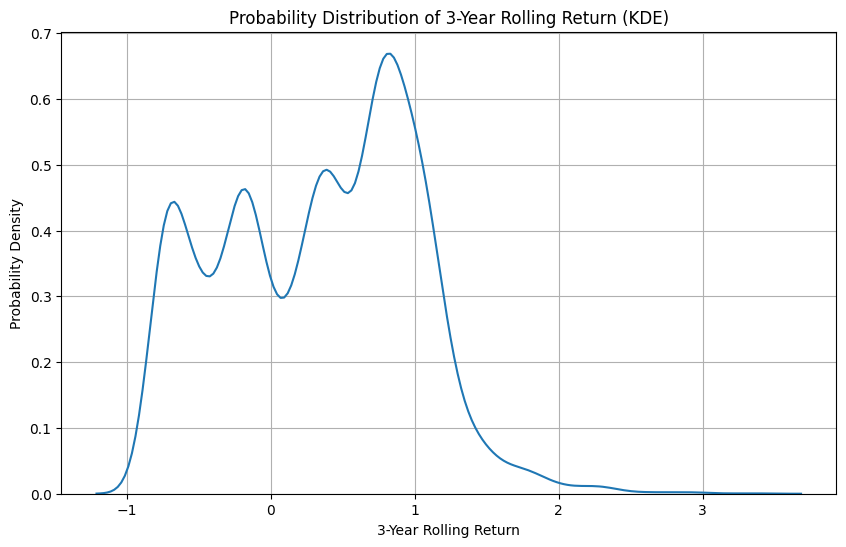

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out NaN values using .notna()
# filtered_data_3Y = data[data['3Y_Rolling_Return'].notna()]

plt.figure(figsize=(10, 6))
sns.kdeplot(filtered_data_3Y['3Y_Rolling_Return'])
plt.title('Probability Distribution of 3-Year Rolling Return (KDE)')
plt.xlabel('3-Year Rolling Return')
plt.ylabel('Probability Density')
plt.grid(True)
plt.show()